## EDA

#### Load Cleaned Dataset

In [1]:
# import library
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Load dataset into a dataframe
df = pd.read_csv("../data/processed/cleaned_flipcart_laptop_data.csv")

## Top five observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...


### Business Objective

This EDA focuses on understanding:

- laptop pricing trends
- customer preferences
- brand positioning
- discount strategies
- product competitiveness
- market segmentation

Before dive into dive, we first extract some meaningful features from existing features.

Let's create a new column called **discount_pct** for showing the discount percentage amount for every laptop.

In [3]:
## Create "discount_pct(%)" column
df["discount_pct(%)"] = round(((df["Actual price"] - df["Discount price"]) / df["Actual price"]) * 100, 2)

# Display five observations of discount_pct(%) column
df["discount_pct(%)"].head()

0    38.89
1    19.05
2    27.58
3    38.66
4    52.88
Name: discount_pct(%), dtype: float64

Let's explore Product Name column.

In [4]:
df['Product Name'].sample(5)

665    SAMSUNG Galaxy Book4 Intel Core 7 150U - (16 G...
590    HP Intel Core i3 12th Gen 1215U - (16 GB/512 G...
67     MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...
94     DELL Intel Core i5 12th Gen 1235U - (8 GB/512 ...
409    Lenovo IdeaPad Slim 1 (2024) AMD Ryzen 5 Hexa ...
Name: Product Name, dtype: str

We know that it contains all information about laptop.

Now we will extract information from it and create some other columns "processor", "ram_gb", "storage_gb", "storage_type".

In [5]:
## Import re module
import re

def extract_specs(name):
    specs = {}
    
    # Brand: first token
    specs['brand'] = name.split()[0]
    
    # CPU family: grab from Intel/AMD up to the next hyphen or opening parenthesis
    cpu_match = re.search(r'((?:Intel|AMD)[^-^(]+)', name, re.IGNORECASE)
    specs['processor'] = cpu_match.group(1).strip() if cpu_match else None
    
    # RAM size (first appearance of "NN GB" that is not storage)
    # We'll exclude matches immediately followed by SSD/HDD/EMMC
    ram_match = re.search(r'(\d+)\s*GB(?!\s*(?:SSD|HDD|EMMC))', name, re.IGNORECASE)
    specs['ram_gb'] = int(ram_match.group(1)) if ram_match else None
    
    # Storage: find all matches of capacity + unit + type
    stor_matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*(GB|TB)\s*(SSD|HDD|EMMC)', 
        name, re.IGNORECASE
    )
    for size, unit, dtype in stor_matches:
        sz = float(size)
        if unit.upper() == 'TB':
            sz *= 1024
           
        specs['storage_gb'] = int(sz)
        specs['storage_type'] =  dtype.upper()

    return specs

# apply to DataFrame
extracted = df['Product Name'].apply(extract_specs).apply(pd.Series)

# Display first 5 observations of the extracted dataframe
extracted.head()

,brand,processor,ram_gb,storage_gb,storage_type
0,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [6]:
## Basic information of **extracted** dataframe
extracted.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         953 non-null    str    
 1   processor     932 non-null    str    
 2   ram_gb        952 non-null    float64
 3   storage_gb    944 non-null    float64
 4   storage_type  944 non-null    str    
dtypes: float64(2), str(3)
memory usage: 37.4 KB


In [7]:
## Concatenate "df" and "extracted" dataframes
df = pd.concat([df, extracted], axis=1)

## Display first 5 observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...,38.66,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...,52.88,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [8]:
# Check the information about the data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     953 non-null    str    
 1   ProductID        953 non-null    str    
 2   Actual price     953 non-null    float64
 3   Discount price   953 non-null    float64
 4   Stars            953 non-null    str    
 5   Rating           953 non-null    str    
 6   Reviews          953 non-null    str    
 7   Description      953 non-null    str    
 8   Link             953 non-null    str    
 9   discount_pct(%)  953 non-null    float64
 10  brand            953 non-null    str    
 11  processor        932 non-null    str    
 12  ram_gb           952 non-null    float64
 13  storage_gb       944 non-null    float64
 14  storage_type     944 non-null    str    
dtypes: float64(5), str(10)
memory usage: 111.8 KB


In [9]:
# Check how many null values contains each column of the dataframe df
df.isnull().sum()

Product Name        0
ProductID           0
Actual price        0
Discount price      0
Stars               0
Rating              0
Reviews             0
Description         0
Link                0
discount_pct(%)     0
brand               0
processor          21
ram_gb              1
storage_gb          9
storage_type        9
dtype: int64

In [10]:
# Check the % value 
((df["processor"].isnull().sum())/len(df))*100 + ((df["storage_gb"].isnull().sum())/len(df))*100 +((df["storage_type"].isnull().sum())/len(df))*100

np.float64(4.092339979013642)

In [11]:
# Drop null values
df.dropna(inplace=True)

# Check the information about the data frame
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    str    
 5   Rating           923 non-null    str    
 6   Reviews          923 non-null    str    
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
dtypes: float64(5), str(10)
memory usage: 115.4 KB


### 1. Executive Business Overview

#### Business Question

**What is the overall condition of the laptop marketplace?**

##### Total Products

In [12]:
## Total no. of products
df.shape[0]

923

##### Average Laptop Price

In [13]:
df["Discount price"].mean()

np.float64(54495.81798483207)

##### Average Discount Percentage

In [14]:
df['discount_pct(%)'].mean()

np.float64(28.845330444203686)

##### Average Product Rating

In [15]:
## Convert Ratings column object into float
df["Rating"] = df["Rating"].str.replace("Ratings", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)

# Display Ratings column
df["Rating"] 

0         7.0
1         0.0
2      1805.0
3      6977.0
4      1263.0
        ...  
948     508.0
949     108.0
950    3897.0
951      53.0
952    5540.0
Name: Rating, Length: 923, dtype: float64

In [16]:
df['Rating'].mean()

np.float64(997.3315276273023)

##### Average Product Stars

In [17]:
## Convert Ratings column object into float
df["Stars"] = df['Stars'].str.replace("NIL", "0").astype(float)

# Display Ratings column
df["Stars"] 

0      3.9
1      0.0
2      4.2
3      4.2
4      4.2
      ... 
948    4.4
949    4.1
950    4.3
951    3.8
952    4.2
Name: Stars, Length: 923, dtype: float64

In [18]:
df["Stars"].mean()

np.float64(3.5810400866738896)

#### Business Insight

- The marketplace contains a wide range of laptop products across multiple price segments.
- Average pricing (54495.8) indicates a strong mid-range market competition.

#####  **Brand Analysis**
#### Business Question

**Which brands dominate the marketplace?**

##### Brand Distribution


In [19]:
df["brand"].value_counts()

brand
HP           226
MSI          172
Lenovo       171
ASUS         115
Thomson       83
Acer          54
DELL          41
Infinix       20
SAMSUNG       11
ZEBRONICS      7
Colorful       6
CHUWI          5
Avita          4
Ultimus        2
realme         2
AXL            1
GIGABYTE       1
Mi             1
Vaio           1
Name: count, dtype: int64

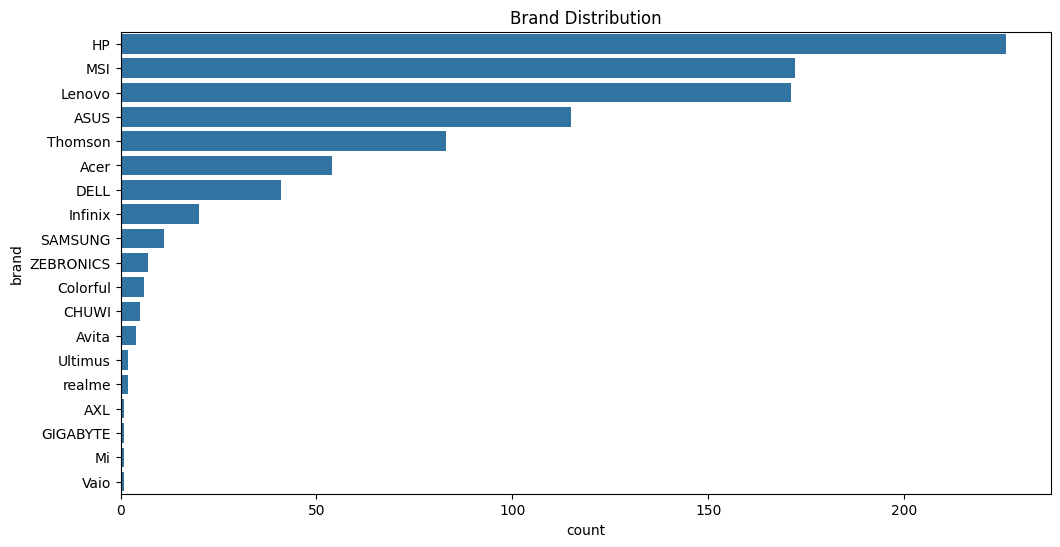

In [20]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, y="brand", order=df["brand"].value_counts().index)

plt.title("Brand Distribution")
plt.show()

##### Total sales amount by each brand

In [21]:
# Check total discount price by each brand
brandwise_total_sell_price = df.groupby(["brand"])["Discount price"].sum().sort_values(ascending=False)
brandwise_total_sell_price

brand
MSI          12109351.0
HP           11047445.0
Lenovo        8801200.0
ASUS          7164594.0
Acer          3210626.0
Thomson       2833636.0
DELL          1969053.0
SAMSUNG       1022890.0
Infinix        863511.0
Colorful       509940.0
ZEBRONICS      259930.0
Avita          108462.0
realme          99989.0
CHUWI           96950.0
GIGABYTE        63990.0
Vaio            45042.0
Ultimus         37989.0
Mi              37052.0
AXL             17990.0
Name: Discount price, dtype: float64

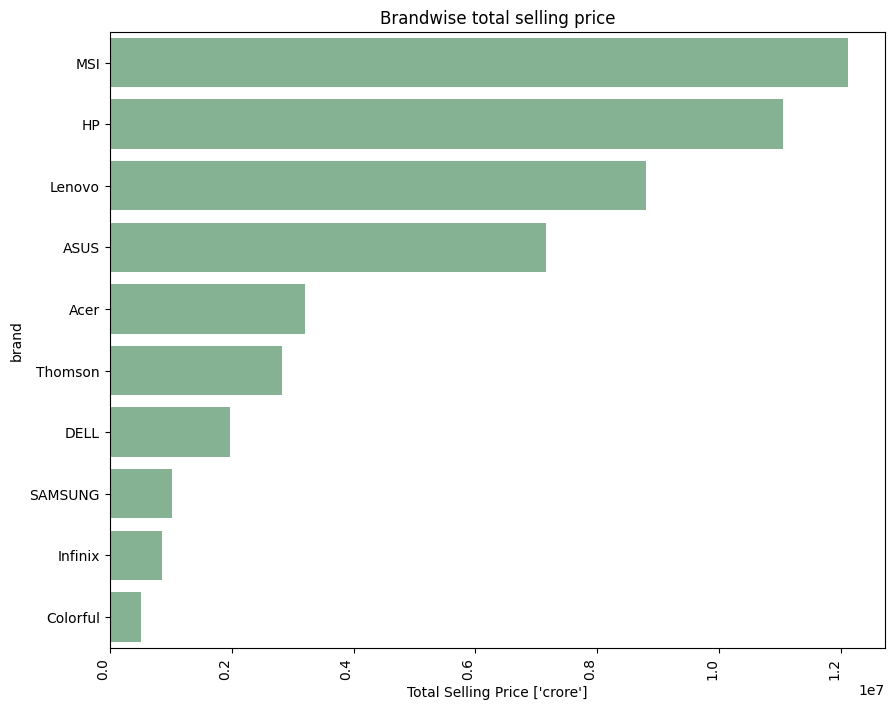

In [22]:
plt.figure(figsize=(10,8))

sns.set_palette("crest")

## Top 10 brands by total sales volume
sns.barplot(brandwise_total_sell_price.head(10), orient='h')

# Add xticks
plt.xticks(rotation=90, ha="right")

# Xlabel
plt.xlabel("Total Selling Price ['crore']")
# Add title
plt.title("Brandwise total selling price")

plt.show();

**Comments:**

Based on the visualization, the **MSI, HP, Lenovo, and ASUS** brands significantly outperform others in total sales volume.

##### Business Insight

- HP, Lenovo, and ASUS dominate the marketplace.

### 2. Price Dynamics


##### **Brand-Wise Pricing Analysis**

#### Business Question

**Which brands have the highest average pricing?**

#### Average selling price of laptop by each brand

In [23]:
avg_laptop_price_brandwise = df.groupby(['brand'])["Discount price"].mean()
avg_laptop_price_brandwise

brand
ASUS         62300.817391
AXL          17990.000000
Acer         59456.037037
Avita        27115.500000
CHUWI        19390.000000
Colorful     84990.000000
DELL         48025.682927
GIGABYTE     63990.000000
HP           48882.500000
Infinix      43175.550000
Lenovo       51469.005848
MSI          70403.203488
Mi           37052.000000
SAMSUNG      92990.000000
Thomson      34140.192771
Ultimus      18994.500000
Vaio         45042.000000
ZEBRONICS    37132.857143
realme       49994.500000
Name: Discount price, dtype: float64

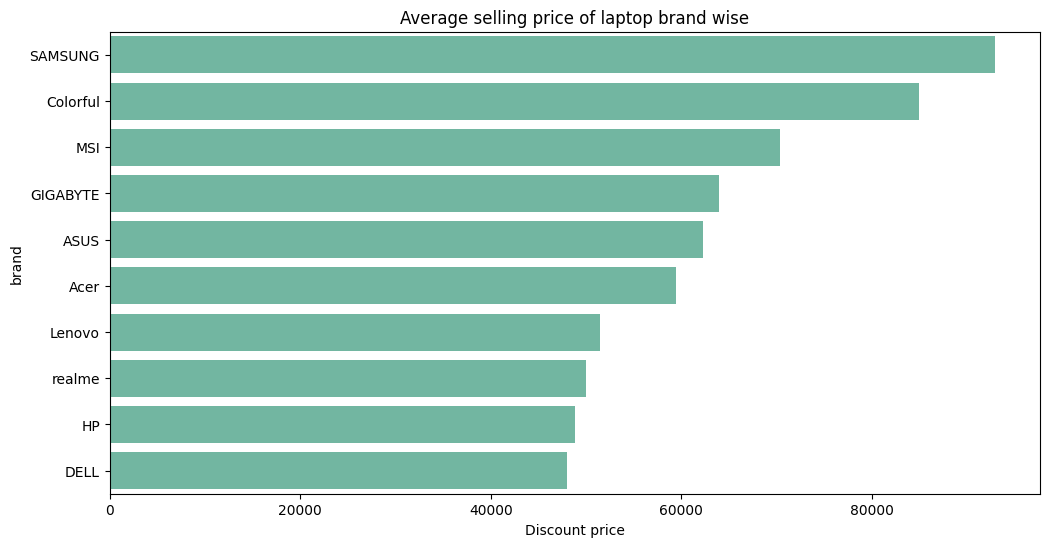

In [24]:
plt.figure(figsize=(12,6))

sns.set_palette("Set2") # Try "magma", "Set2", "crest" or "flare"

# Use catplot to see "average actual selling price of laptop" by top 10 brands
sns.barplot(data=avg_laptop_price_brandwise.sort_values(ascending=False).head(10), orient='h')

# Add title
plt.title("Average selling price of laptop brand wise")

plt.show();

**Comments:**

We can see from the above figure that `SAMSUNG, Colorful, MSI, GIGABYTE` brands avrage selling price is high more than other brands.


##### Business Insight
- **SAMSUNG, Colorful, MSI, GIGABYTE** brands have the highest average pricing.

##### **Price distribution**

In [25]:
## check the descriptive statistics of numeric values
df.describe()

,Actual price,Discount price,Stars,Rating,discount_pct(%),ram_gb,storage_gb
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,75354.066089,54495.817985,3.581040,997.331528,28.845330,11.813651,553.152763
std,36051.320904,31239.227218,1.532652,1784.997022,9.862427,5.011045,218.346988
min,21990.000000,13990.000000,0.000000,0.000000,0.670000,4.000000,32.000000
25%,51967.000000,35990.000000,3.800000,3.000000,21.715000,8.000000,512.000000
50%,69890.000000,47990.000000,4.200000,70.000000,28.110000,8.000000,512.000000
75%,88990.000000,63990.000000,4.300000,997.000000,36.165000,16.000000,512.000000
max,499990.000000,439990.000000,5.000000,12482.000000,60.020000,64.000000,2048.000000


**Comments:**

From the above scenario, we can observe that **mean > median** for `Actual price` and `Discount price` columns, so the distribution of `Actual price` and `Discount price` columns are right skewed. 

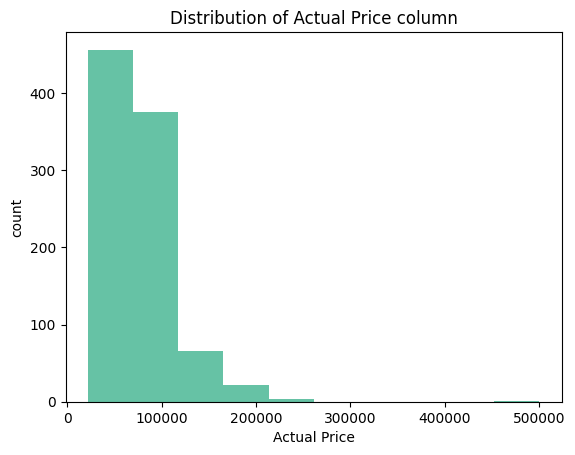

In [26]:
plt.figure()

# Plot a histogram of Actual price column
plt.hist(df["Actual price"])

# Add x-axis label
plt.xlabel("Actual Price")

# Add y-axis label
plt.ylabel("count")

# Add title
plt.title("Distribution of Actual Price column");

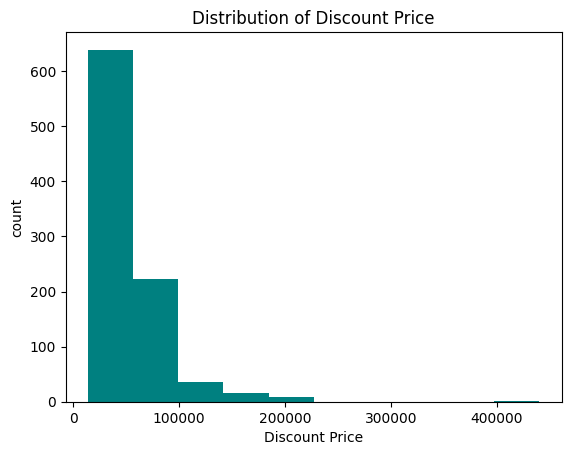

In [27]:
plt.figure()

# Plot a histogram of Actual price column
plt.hist(df["Discount price"], color='#008080')

# Add x-axis label
plt.xlabel("Discount Price")

# Add y-axis label
plt.ylabel("count")

# Add title
plt.title("Distribution of Discount Price");

### Find the relationship between actual price and discount price columns

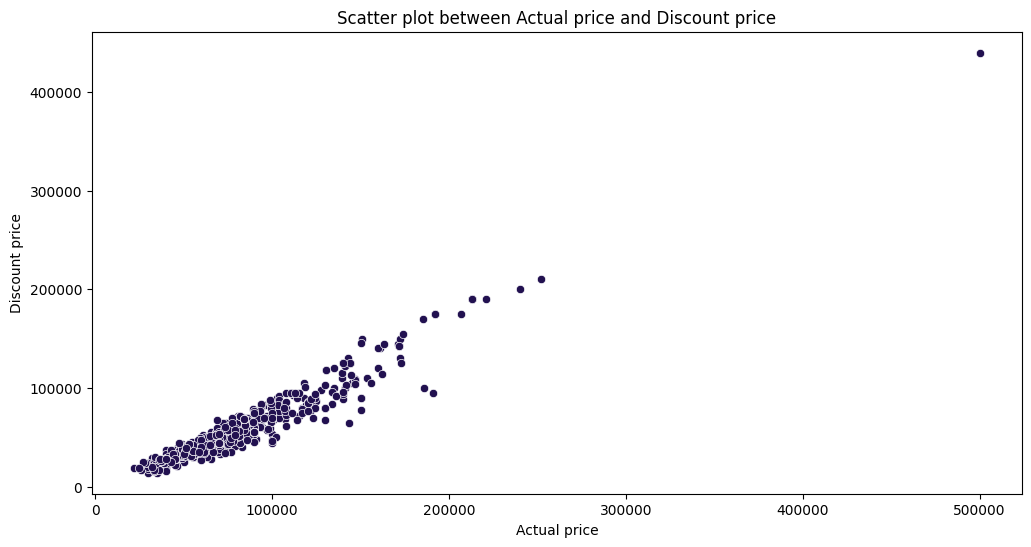

In [28]:
plt.figure(figsize=(12,6))

sns.set_palette("magma")

# Use scatter plot to see the relationship between actual price and discount price
sns.scatterplot(data=df, x="Actual price", y="Discount price")

# Add title
plt.title("Scatter plot between Actual price and Discount price");

**Comments:** 

From the above figure, it is cleary seen that there is a strong relationship between Actual price and Discount price. How many strong? Let's find the correlation between them.

In [29]:
corr_val = df["Actual price"].corr(df["Discount price"])
corr_val

np.float64(0.9601848577442852)

**Comments:**

The correlation coefficient between Actual price and Discount price is 0.9602, i.e., they are positively correlated.

#### Business Question

**Identify which brands offering the top 20 most expensive laptops?**

Text(0.5, 1.0, 'The brands offering the top 20 most expensive laptops')

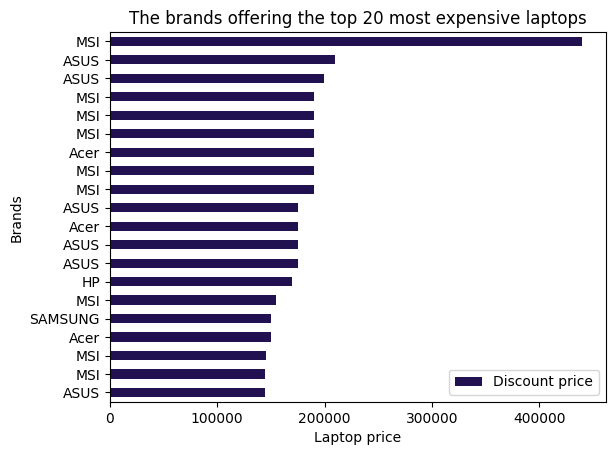

In [30]:
df[["brand", "Discount price"]].set_index(['brand']).sort_values(by="Discount price").tail(20).plot(kind='barh')

# xlabel
plt.xlabel("Laptop price")
# ylabel
plt.ylabel("Brands")

# Title
plt.title("The brands offering the top 20 most expensive laptops")

##### Business Insight

- It is clear that **MSI, ASUS, Acer, HP, Samsung** sold highest expensive laptops.

### 3. Product Analysis Dashboard

#### RAM vs Price Analysis

#### Business Question

**Does higher RAM increase laptop pricing?**

In [31]:
# Average selling price of laptop for different GB RAM
avg_laptop_price_ramwise = (df.groupby(["ram_gb"])["Discount price"].mean()).reset_index()
avg_laptop_price_ramwise

,ram_gb,Discount price
0,4.0,21512.437500
1,8.0,41041.075594
2,12.0,62490.000000
3,16.0,68258.213592
4,24.0,99990.000000
5,32.0,162190.000000
6,64.0,439990.000000


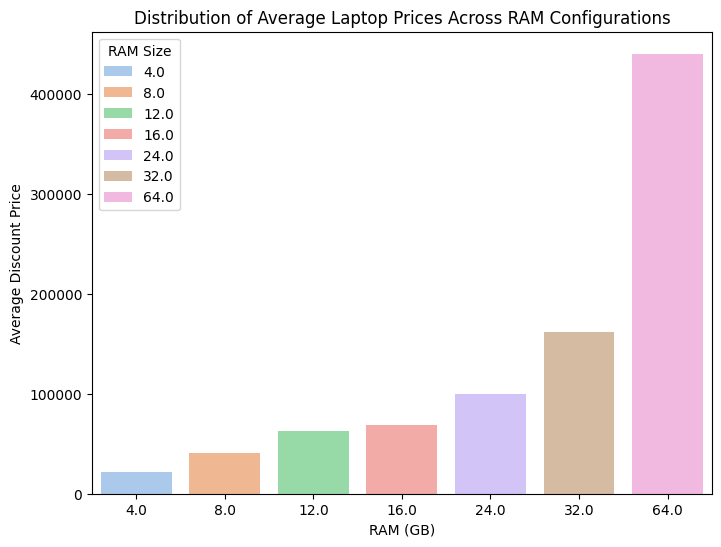

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8, 6))

# Create the bar plot
sns.barplot(x="ram_gb", y="Discount price", data=avg_laptop_price_ramwise, hue="ram_gb", palette="pastel")

plt.title("Distribution of Average Laptop Prices Across RAM Configurations")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Discount Price")

# Add legend
plt.legend(title="RAM Size", loc="upper left")

# Display chart
plt.show()


##### Business Insight 
- Yes, higher RAM directly increases laptop pricing, showing an exponential price growth pattern.

#### Storage vs Price Analysis

#### Business Question

**How does storage capacity affect pricing?**

In [33]:
avg_laptop_price_with_storageType = df.groupby(["storage_type"])["Discount price"].mean().reset_index()
avg_laptop_price_with_storageType

,storage_type,Discount price
0,EMMC,19799.333333
1,HDD,27420.300000
2,SSD,55376.889755


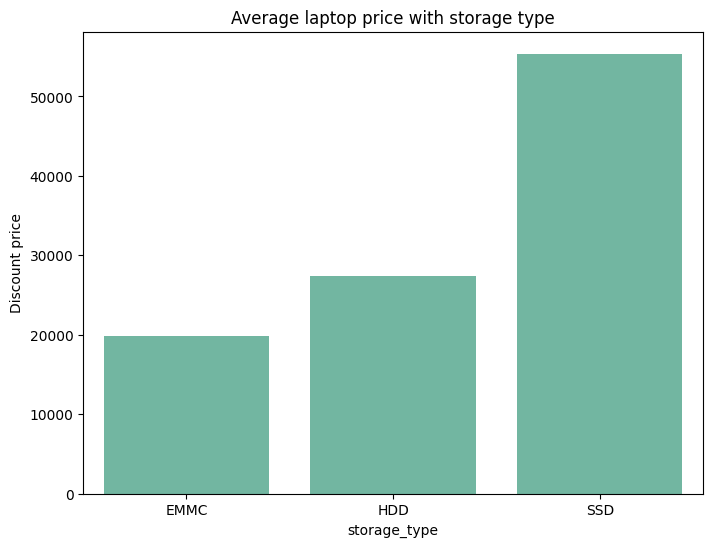

In [34]:
plt.figure(figsize=(8,6))

sns.set_palette("Set2")

sns.barplot(data=avg_laptop_price_with_storageType, x="storage_type", y="Discount price")

# Add title
plt.title("Average laptop price with storage type");

##### Business Insight:
- SSD-based laptops command higher pricing compared to HDD-based products.
- Larger storage configurations are associated with premium devices.

#### Processor Analysis

#### Business Question

**Which processor categories dominate the market?**

In [35]:
# Store df into df_processor dataframe
df_processor = df

# Define a function
def assign_processor_tier(cpu):
    if pd.isna(cpu):
        return None
    cpu = cpu.lower()
    if 'core i3' in cpu or 'ryzen 3' in cpu or 'pentium' in cpu or 'celeron' in cpu:
        return 'Entry'
    elif 'core i5' in cpu or 'ryzen 5' in cpu:
        return 'Mid'
    elif 'core i7' in cpu or 'ryzen 7' in cpu:
        return 'High'
    elif 'core i9' in cpu or 'ryzen 9' in cpu or 'core ultra' in cpu:
        return 'Ultra'
    else:
        return 'Other'

# Apply to our DataFrame
df_processor['processor_tier'] = df_processor['processor'].apply(assign_processor_tier)

# Display first 3 observation
df_processor.head(3)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7.0,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,0.0,0.0,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,1805.0,143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry


In [36]:
df.head(1)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7.0,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid


In [37]:
# Calculate market volume share per tier
tier_counts = df_processor["processor_tier"].value_counts().reset_index()
tier_counts.columns = ["processor_tier", "count"]
tier_counts

,processor_tier,count
0,Mid,364
1,Entry,305
2,High,181
3,Ultra,46
4,Other,27


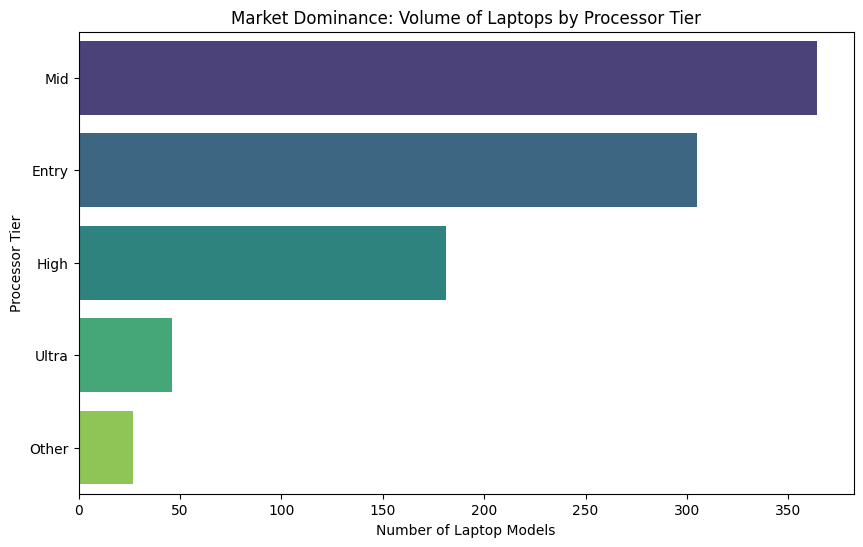

In [38]:
plt.figure(figsize=(10, 6))

# Plot the volume dominance
sns.barplot(x="count", y="processor_tier", data=tier_counts, hue="processor_tier", palette="viridis", legend=False)

plt.title("Market Dominance: Volume of Laptops by Processor Tier")
plt.xlabel("Number of Laptop Models")
plt.ylabel("Processor Tier")
plt.show()

#### which brands dominates these high-volume tiers?

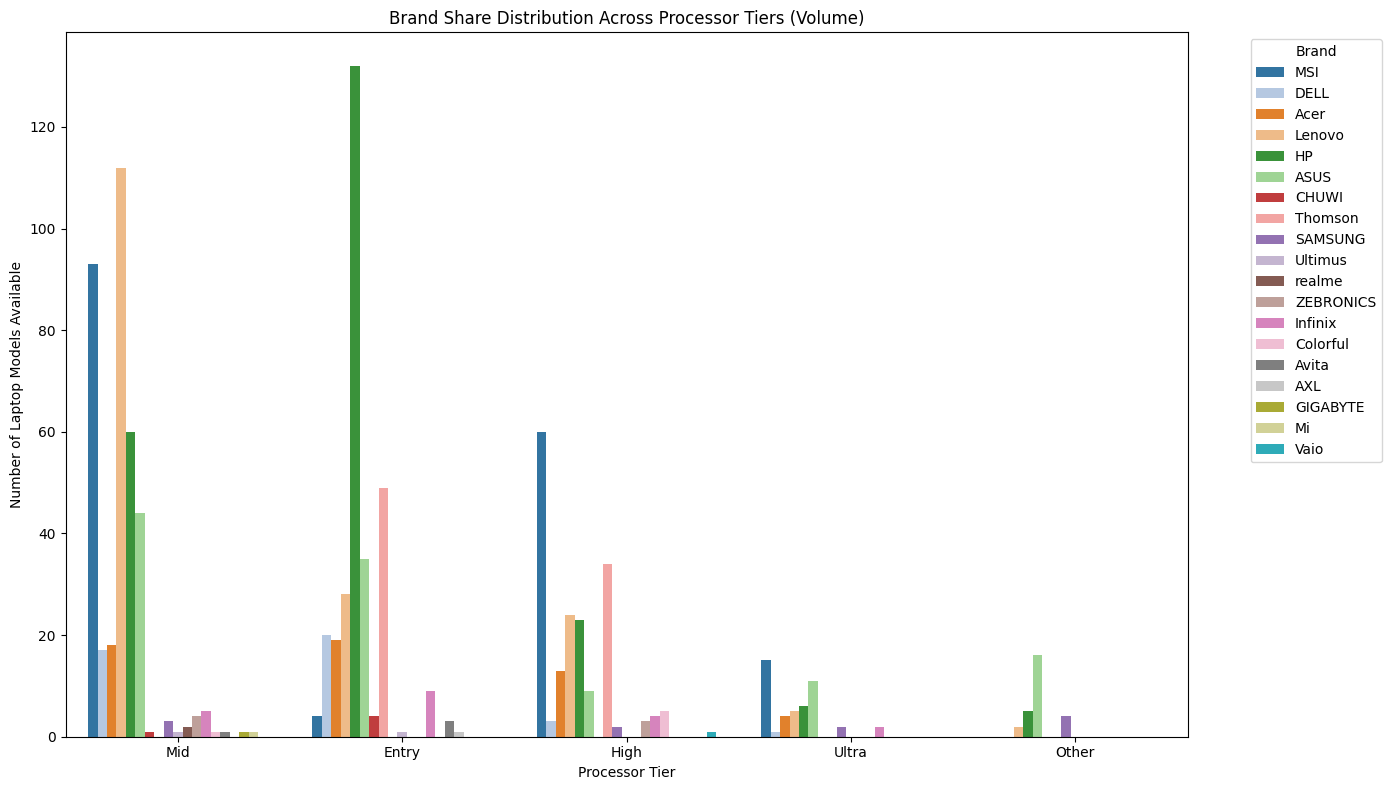

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the raw data to see brand distributions across tiers
plt.figure(figsize=(14, 8))

# Create a count plot grouped by tier and colored by brand
# Ordering by exact volume sequence
sns.countplot(x="processor_tier", hue="brand", data=df_processor, order=["Mid", "Entry", "High", "Ultra", "Other"], palette="tab20")

plt.title("Brand Share Distribution Across Processor Tiers (Volume)")
plt.xlabel("Processor Tier")
plt.ylabel("Number of Laptop Models Available")
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


##### Business Insight:
- Mid (364) and Entry (305) tiers dominate the market volume.
- The business health relies heavily on Mid and Entry configurations. A combined volume of 669 models means these tiers attract the highest consumer search traffic.
- The Ultra tier (46 models) is a tiny fraction of catalog. It should be treated as a prestige marketing tier, not a primary volume driver.

#### What is the average price distribution for each brand-to-processor segment?

In [40]:
processor_tier_price = df_processor.groupby(["brand", "processor_tier"])["Discount price"].mean().sort_values(ascending=False).reset_index()
processor_tier_price

,brand,processor_tier,Discount price
0,ASUS,Ultra,155171.818182
1,SAMSUNG,Ultra,144990.000000
2,MSI,Ultra,141590.000000
3,SAMSUNG,High,117990.000000
4,Acer,High,97336.923077
5,DELL,Ultra,94990.000000
6,Acer,Ultra,94990.000000
7,HP,Ultra,93406.666667
8,DELL,High,92256.666667
9,Lenovo,Ultra,90990.000000


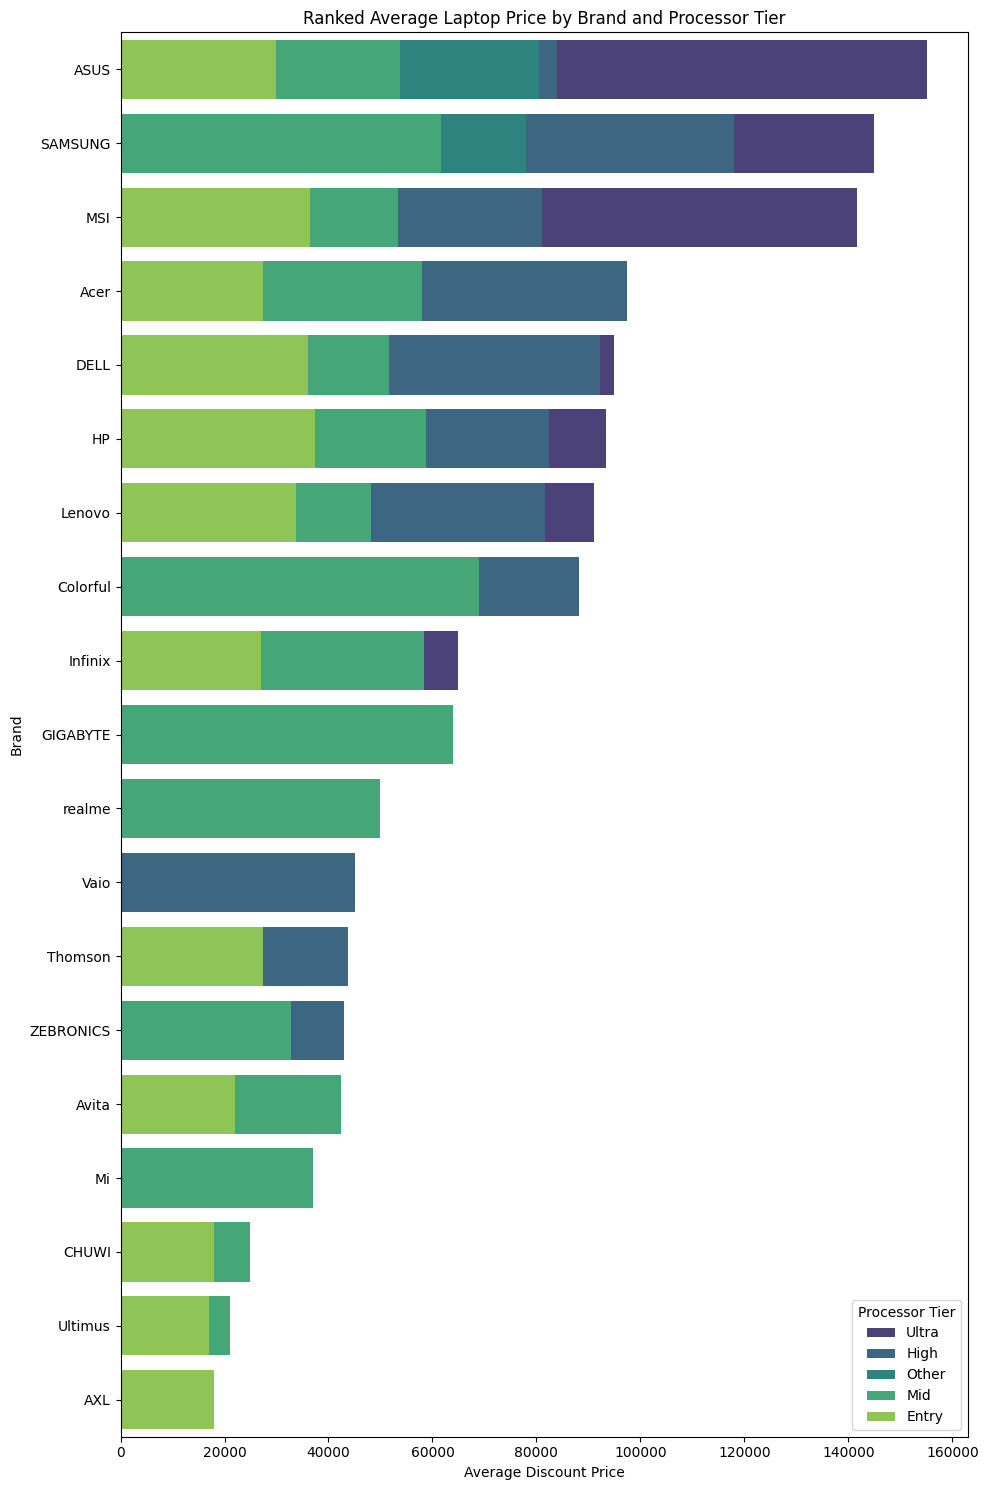

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a taller figure size to fit all 52 rows comfortably
plt.figure(figsize=(10, 15))

# Plot horizontal bars
sns.barplot(x="Discount price",y="brand", hue="processor_tier", data=processor_tier_price, palette="viridis", dodge=False) # Keeps bars aligned per brand

plt.title("Ranked Average Laptop Price by Brand and Processor Tier")
plt.xlabel("Average Discount Price")
plt.ylabel("Brand")
plt.legend(title="Processor Tier", loc="lower right")
plt.tight_layout()
plt.show()


**Comment:**
- ASUS, SAMSUNG, and MSI aggressively lock down the ultra-premium segment, commanding the highest average prices (~₹1.4L - ₹1.55L) exclusively through Ultra tier processors.
- Core market brands like HP, DELL, and Lenovo maintain strict pricing discipline, where costs drop predictably as you move down from Ultra to High, Mid, and Entry tiers.
- Value brands like Infinix, Colorful, and GIGABYTE are aggressively stretching upward, pricing their Mid and High tiers (~₹58K - ₹68K) to directly challenge legacy manufacturers.
- CHUWI, Ultimus, and AXL strictly anchor the entry-level floor, completely bypassing performance tiers to cap their average prices below ₹18,000.

### 4. Customer Insights Dashboard

#### Discount Analysis

#### Business Question

**How are discounts distributed across products?**

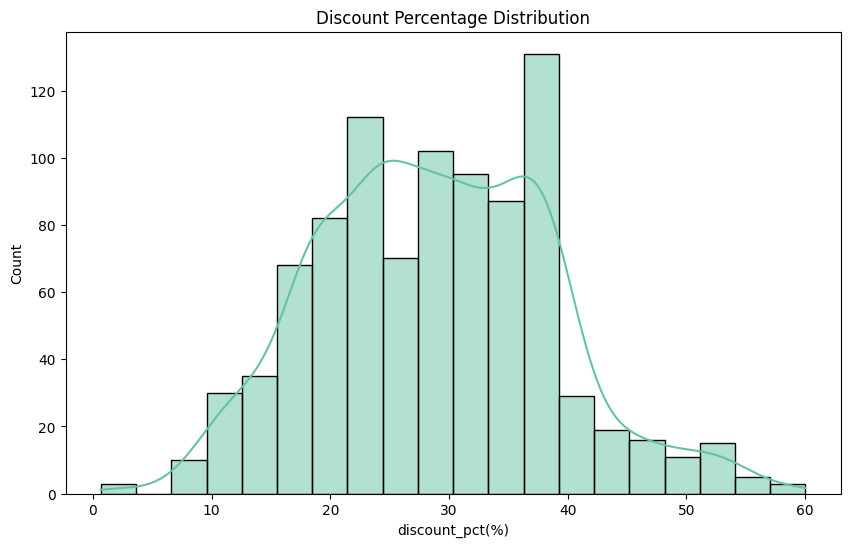

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(df["discount_pct(%)"], bins=20, kde=True)
plt.title("Discount Percentage Distribution")

plt.show()

##### Business Insight:

- Most products fall within moderate discount ranges.
- Extremely high discounts are relatively uncommon.

#### Business Question
**Which brands are least likely to offer deep discounts on their laptops?**

In [43]:
avg_discount_brandwise = df.groupby(["brand"])["discount_pct(%)"].mean().sort_values(ascending=True).reset_index()
avg_discount_brandwise

,brand,discount_pct(%)
0,SAMSUNG,18.002727
1,HP,23.111195
2,MSI,25.613895
3,ASUS,28.701913
4,Acer,29.550741
5,Colorful,30.928333
6,realme,31.055000
7,DELL,31.678293
8,Lenovo,33.488421
9,Infinix,34.512000


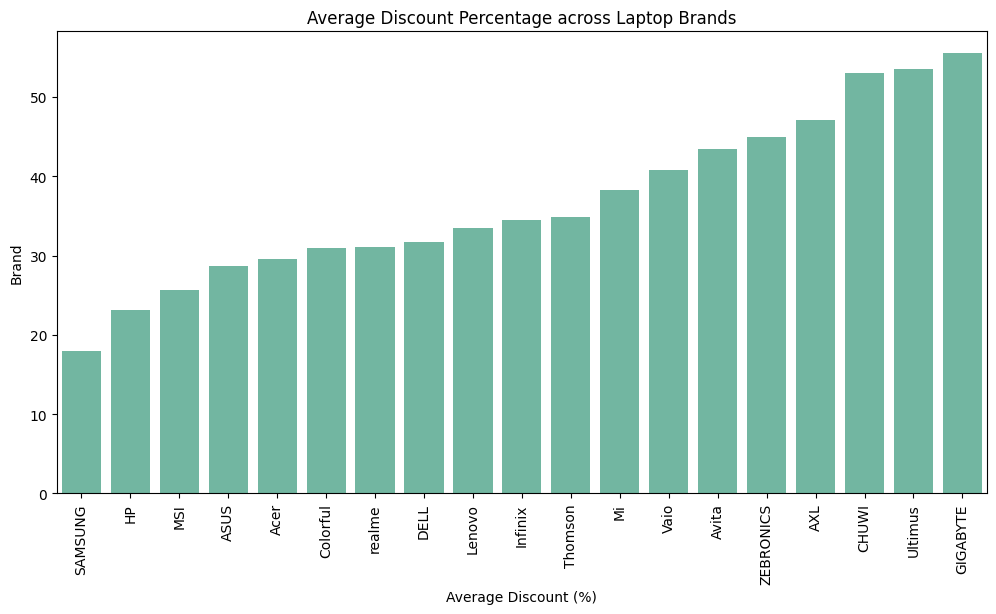

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(avg_discount_brandwise, x="brand", y="discount_pct(%)")

# Add title
plt.title("Average Discount Percentage across Laptop Brands")
plt.xlabel("Average Discount (%)")
plt.ylabel("Brand")

plt.xticks(rotation=90);

**Comments:**
- Samsung (18%) and HP (23.1%) maintain the highest price discipline, offering minimal discounts to protect their strong brand equity and premium margins.
- Dell (31.7%) and Lenovo (33.5%) discount noticeably deeper than HP, using aggressive price drops to win market share in identical business and student segments.
- Mid-tier and smartphone-first brands like realme (31%) and Infinix (34.5%) lean heavily on 30%+ discount baselines to lure price-sensitive buyers away from legacy players.
- Budget and niche brands (CHUWI, Ultimus, GIGABYTE) cross the 50% discount threshold, relying strictly on aggressive price slashing as their primary tool to move inventory.

##### Business Insight:
- SAMSUNG, HP, DELL, LENOVO are least likely to offer deep discounts on their laptops.

#### Market Segmentation

#### Business Question

**How is the laptop market segmented?**

In [45]:
df.describe()

,Actual price,Discount price,Stars,Rating,discount_pct(%),ram_gb,storage_gb
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,75354.066089,54495.817985,3.581040,997.331528,28.845330,11.813651,553.152763
std,36051.320904,31239.227218,1.532652,1784.997022,9.862427,5.011045,218.346988
min,21990.000000,13990.000000,0.000000,0.000000,0.670000,4.000000,32.000000
25%,51967.000000,35990.000000,3.800000,3.000000,21.715000,8.000000,512.000000
50%,69890.000000,47990.000000,4.200000,70.000000,28.110000,8.000000,512.000000
75%,88990.000000,63990.000000,4.300000,997.000000,36.165000,16.000000,512.000000
max,499990.000000,439990.000000,5.000000,12482.000000,60.020000,64.000000,2048.000000


In [46]:
low, mid = [55000, 80000]
print(low, mid)

55000 80000


In [47]:
## Srore df into df_price_tier
df_price_tier = df

# Define function
def budget_range(price):

    if (price <= low):
        return "budget"
    elif (price <= mid):
        return "mid range"
    else:
        return "premium"
    
# Create a new column
df_price_tier["price_tier"] = df_price_tier["Discount price"].apply(budget_range)

# Display the dataframe with 5 observations
df_price_tier.head(3)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier,price_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7.0,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid,budget
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,0.0,0.0,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High,mid range
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,1805.0,143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry,budget


#### Segment Distribution

In [48]:
df_price_tier["price_tier"].value_counts()

price_tier
budget       634
mid range    181
premium      108
Name: count, dtype: int64

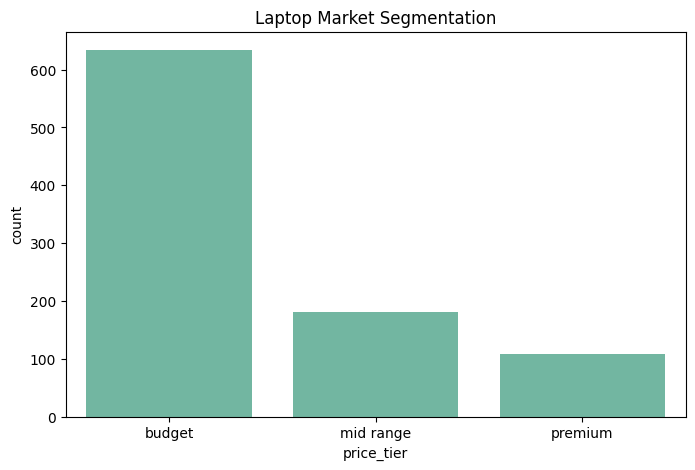

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_price_tier, x="price_tier")

plt.title("Laptop Market Segmentation")

plt.show()

**Comments:**

- From the above analysis, we can observe that, more laptops within budget range i.e., (<=55000) solded out.
- Budget-range laptops dominate the marketplace.
- Premium devices form a smaller but high-value segment.

#### Business Question:
**Which price tier gives shoppers the biggest discount percentage on average?**

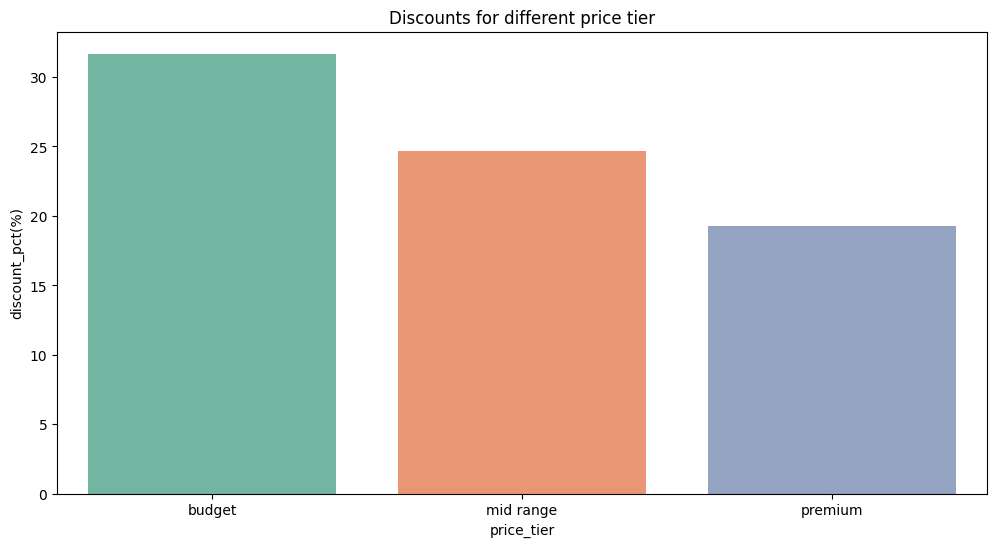

In [50]:
avg_discount_price_tier = df_price_tier.groupby(["price_tier"])["discount_pct(%)"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.barplot(avg_discount_price_tier, x="price_tier", y="discount_pct(%)", hue="price_tier", palette="Set2")

# Add title
plt.title("Discounts for different price tier");

##### Business Insight
- Budget range price tier gives shoppers the biggest discount percentage on average.

#### Price tier VS Ram

#### Business Question

**How do manufacturers scale RAM sizes across budget, mid-range, and premium laptop tiers?**

In [51]:
## Different price tier for different gb ram
price_tier_ram = df.groupby(["price_tier"])["ram_gb"].value_counts().reset_index()

price_tier_ram

,price_tier,ram_gb,count
0,budget,8.0,403
1,budget,16.0,199
2,budget,4.0,32
3,mid range,16.0,120
4,mid range,8.0,59
5,mid range,12.0,2
6,premium,16.0,93
7,premium,32.0,10
8,premium,24.0,3
9,premium,64.0,1


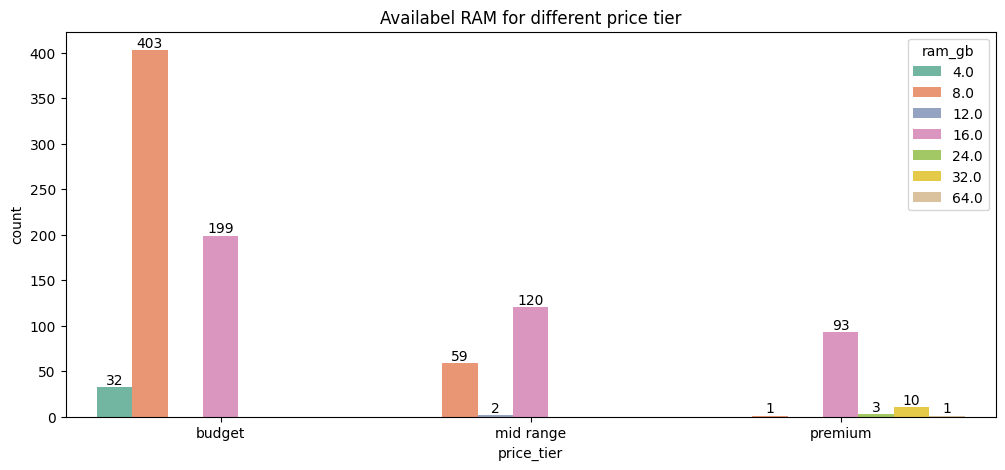

In [52]:
plt.figure(figsize=(12,5))

# Different gb ram for every price tier
ax = sns.barplot(price_tier_ram, x="price_tier", y="count", hue="ram_gb", palette='Set2')

# Add title
plt.title("Availabel RAM for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

##### Business Insight
- 8GB is the absolute standard for the budget segment (403 counts), but 16GB is rapidly encroaching with nearly 200 models, showing that budget buyers now expect decent multitasking performance.
- 16GB is the clear sweet spot for mid-range laptops (120 counts), outnumbering 8GB variants two-to-one, establishing 16GB as the baseline for mainstream consumers.
- The premium tier completely abandons lower specs, standardising heavily on 16GB (93 counts) while exclusively hosting high-margin, specialized configurations like 32GB and 64GB RAM for power users.
- 4GB RAM is restricted solely to the lowest budget tier (32 counts) and is nearing end-of-life status, while odd configurations like 12GB and 24GB remain extreme retail anomalies.

#### Price tier VS Storage

In [53]:
price_tier_storage = df.groupby(["price_tier"])["storage_gb"].value_counts().reset_index()

price_tier_storage

,price_tier,storage_gb,count
0,budget,512.0,519
1,budget,256.0,79
2,budget,1024.0,16
3,budget,128.0,10
4,budget,64.0,9
5,budget,32.0,1
6,mid range,512.0,118
7,mid range,1024.0,57
8,mid range,256.0,6
9,premium,1024.0,57


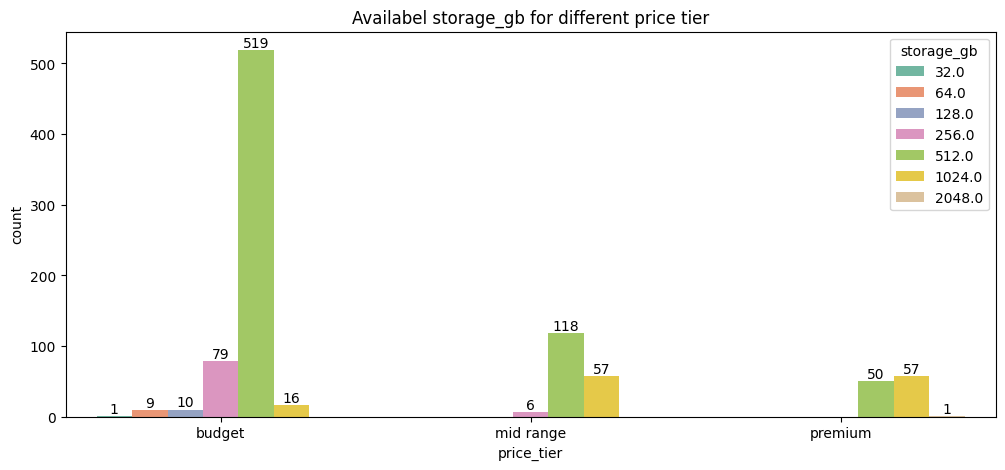

In [54]:
plt.figure(figsize=(12,5))
ax = sns.barplot(price_tier_storage, x="price_tier", y="count", hue="storage_gb", palette='Set2')

# Add title
plt.title("Availabel storage_gb for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

**Comments:**
- 512GB is the absolute market standard, completely dominating both the budget (519 counts) and mid-range (118 counts) tiers as the baseline configuration consumers expect.
- 1024GB (1TB) storage becomes a major player in the mid-range segment (57 counts) and ties for the top spot in the premium - Low storage capacities (128GB and below) are strictly confined to the budget tier with very low counts, proving that micro-storage options are almost entirely obsolete in modern laptops.
- Massive 2048GB (2TB) storage options are virtually non-existent in lower tiers, appearing exclusively as a high-margin rarity (1 count) in the premium segment.

#### Price tier with storage type

In [55]:
# Different price tier for different storage type
price_tier_storage_type = df_price_tier.groupby(["price_tier"])["storage_type"].value_counts().reset_index()

price_tier_storage_type 

,price_tier,storage_type,count
0,budget,SSD,609
1,budget,EMMC,15
2,budget,HDD,10
3,mid range,SSD,181
4,premium,SSD,108


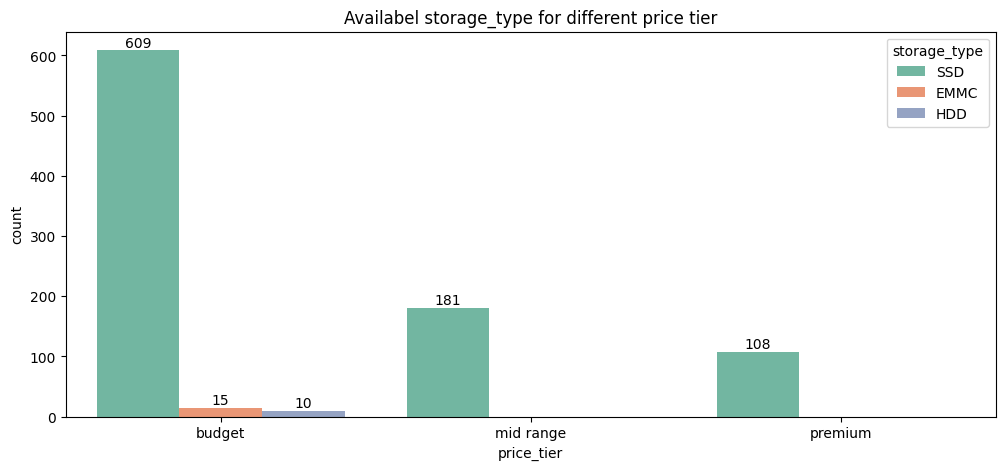

In [56]:
plt.figure(figsize=(12,5))


ax = sns.barplot(price_tier_storage_type, x="price_tier", y="count", hue="storage_type", palette='Set2')

# Add title
plt.title("Availabel storage_type for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

**Comments:**

From above figure we can observe that, only budget range has different type of storage and others has only SSD type.

#### Price tier VS Processor tier

In [57]:
price_tier_processor_type = df_price_tier.groupby(["price_tier"])["processor_tier"].value_counts().reset_index()

price_tier_processor_type 

,price_tier,processor_tier,count
0,budget,Entry,304
1,budget,Mid,265
2,budget,High,56
3,budget,Other,9
4,mid range,Mid,90
5,mid range,High,62
6,mid range,Ultra,15
7,mid range,Other,13
8,mid range,Entry,1
9,premium,High,63


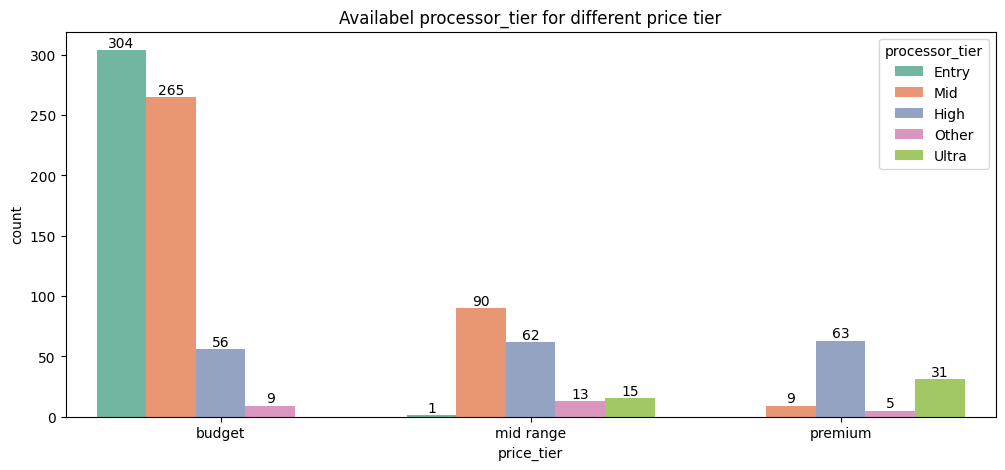

In [58]:
plt.figure(figsize=(12,5))


ax = sns.barplot(price_tier_processor_type , x="price_tier", y="count", hue="processor_tier", palette='Set2')

# Add title
plt.title("Availabel processor_tier for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

**Comments:**

From above figure we can observe that, budget range has high entry level of processor, mid range has mid level of processor, Premium range has more high level of processor.

In [59]:
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    float64
 5   Rating           923 non-null    float64
 6   Reviews          923 non-null    str    
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
 15  processor_tier   923 non-null    str    
 16  price_tier       923 non-null    str    
dtypes: float64(7), str(10)
memory us

In [60]:
# Convert Ratings column object into float
df["Reviews"] = df["Reviews"].str.replace("Reviews", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)
# Display Ratings column
df["Reviews"] 

0        1.0
1        0.0
2      143.0
3      596.0
4      113.0
       ...  
948     77.0
949     16.0
950    457.0
951      5.0
952    485.0
Name: Reviews, Length: 923, dtype: float64

In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 923 entries, 0 to 952
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    str    
 1   ProductID        923 non-null    str    
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    float64
 5   Rating           923 non-null    float64
 6   Reviews          923 non-null    float64
 7   Description      923 non-null    str    
 8   Link             923 non-null    str    
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    str    
 11  processor        923 non-null    str    
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    str    
 15  processor_tier   923 non-null    str    
 16  price_tier       923 non-null    str    
dtypes: float64(8), str(9)
memory usa

##### Rating Trends

**Which laptop brands lead the market in average consumer rating, and how does customer satisfaction rank across competitors?**

In [63]:
# Most rated brand
avg_consumer_rating_brand = df_price_tier.groupby(['brand'])["Rating"].mean().sort_values(ascending=False).reset_index()
avg_consumer_rating_brand

,brand,Rating
0,realme,4317.000000
1,HP,2188.615044
2,Lenovo,1153.409357
3,Avita,1095.000000
4,ASUS,1081.426087
5,Infinix,976.300000
6,Mi,550.000000
7,Acer,525.407407
8,ZEBRONICS,404.571429
9,SAMSUNG,389.818182


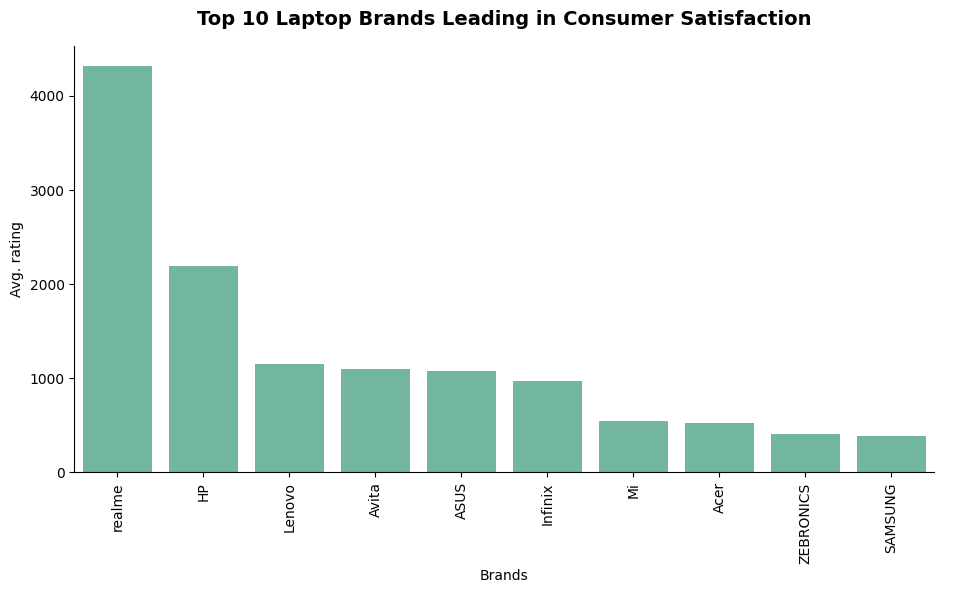

In [ ]:
# Top 10 brands lead the market
sns.catplot(avg_consumer_rating_brand.head(10), x="brand", y="Rating", kind="bar", height=5, aspect=1.9)
# Add title
plt.title("Top 10 Laptop Brands Leading in Consumer Satisfaction", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Brands")
plt.ylabel("Total Consumer Feedback Volume")

# Add xticks
plt.xticks(rotation=90);

##### Business Insight
- **realme** (4,317) and **HP** (2,188) massively dominate consumer engagement, indicating they have the highest sales velocity or the most active online buyer communities.
- **Lenovo, Avita, and ASUS** form a steady second tier (clustering around 1,000+ ratings), proving they maintain a highly stable, competitive baseline presence in the market.
- Premium heavyweights like **SAMSUNG** (389) and **MSI** (103) show low rating volumes, confirming their status as low-volume, high-margin niche players that do not chase mass-market sales.
- Brands at the bottom like GIGABYTE (11) and Thomson (3) suffer from a critical lack of consumer feedback, making it difficult for new buyers to trust or validate their products.

**Which laptop brands successfully maintain high-quality star ratings while operating at a massive consumer sales volume?**

In [ ]:
avg_consumer_rating_stars_brand = df_price_tier.groupby(['brand'])[["Rating", "Stars"]].mean().sort_values(by=["Rating"] ,ascending=False).reset_index()
avg_consumer_rating_stars_brand

,brand,Rating,Stars
0,realme,4317.000000,4.350000
1,HP,2188.615044,3.761062
2,Lenovo,1153.409357,3.970760
3,Avita,1095.000000,3.775000
4,ASUS,1081.426087,3.278261
5,Infinix,976.300000,3.950000
6,Mi,550.000000,4.300000
7,Acer,525.407407,3.490741
8,ZEBRONICS,404.571429,3.842857
9,SAMSUNG,389.818182,4.427273


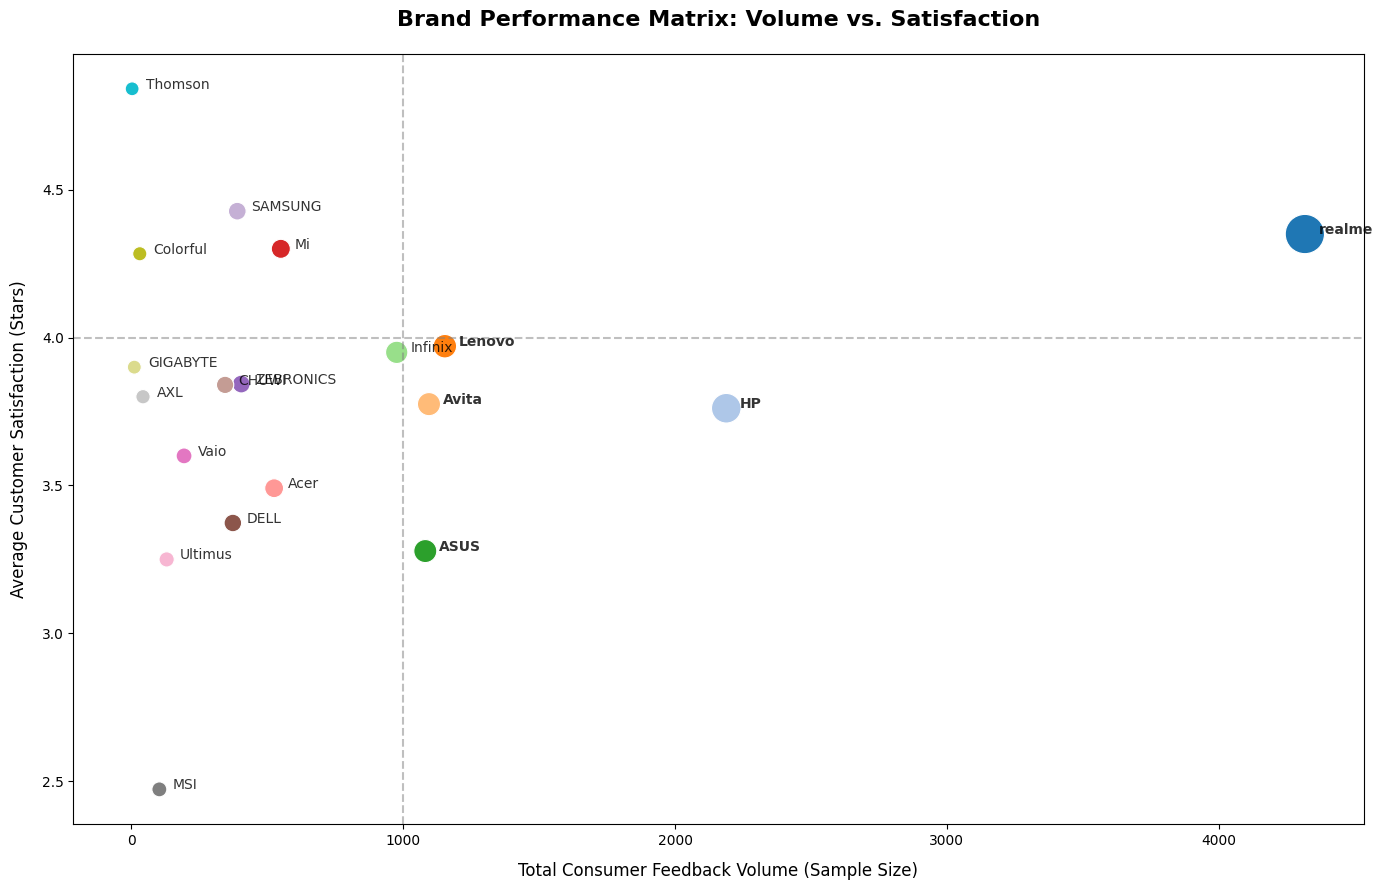

In [ ]:
plt.figure(figsize=(14, 9))

# Create the scatter plot
sns.scatterplot(x="Rating", y="Stars", data=avg_consumer_rating_stars_brand, hue="brand", size="Rating", sizes=(100, 800), palette="tab20", legend=False)

# Label points with brand names for clarity
for i in range(len(avg_consumer_rating_stars_brand)):
    plt.text(
        x=avg_consumer_rating_stars_brand["Rating"][i] + 50, # Slight offset
        y=avg_consumer_rating_stars_brand["Stars"][i],
        s=avg_consumer_rating_stars_brand["brand"][i],
        fontweight="bold" if avg_consumer_rating_stars_brand["Rating"][i] > 1000 else "regular",
        alpha=0.8,
        fontsize=10
    )

# Add clear quadrant lines based on mid-points
plt.axhline(y=4.0, color="gray", linestyle="--", alpha=0.5) # 4-star benchmark
plt.axvline(x=1000, color="gray", linestyle="--", alpha=0.5) # High volume line


plt.title("Brand Performance Matrix: Volume vs. Satisfaction", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Total Consumer Feedback Volume (Sample Size)", fontsize=12, labelpad=10)
plt.ylabel("Average Customer Satisfaction (Stars)", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()


##### Business Insights
- **realme** achieves a rare retail feat by maintaining an exceptional satisfaction rating (**4.35 Stars**) despite managing the highest customer feedback volume (4,317 Ratings), signaling immense market trust and product reliability.
- **SAMSUNG** demonstrates classic premium optimization, capturing very high customer satisfaction (4.43 Stars) while operating at a smaller, more controlled sales volume tier (389 Ratings).
- Massive volume leaders like HP, Lenovo, and ASUS struggle to maintain premium satisfaction benchmarks, dropping down to sub-4.0 star scores (3.76, 3.97, and 3.27 Stars respectively), which indicates widespread post-purchase customer friction.
- MSI faces an alarming quality perception issue, crashing to the lowest market score of 2.47 Stars despite having over 103 review entries, screaming for immediate technical and product quality investigation.
- Thomson sits at an elite 4.84 Stars, but this is built on a tiny sample size of only 3 Ratings, making it a statistical outlier rather than a true reflection of market leadership.

**What is the ultimate brand positioning matrix for laptops, and how do consumer adoption volume, customer satisfaction (Stars), average retail pricing, and promotional discount strategies interact across competing brands?**

In [77]:
avg_consumer_rating_stars_price_discount_brand = df_price_tier.groupby(['brand'])[["Rating", "Stars", "Discount price", "discount_pct(%)"]].mean().sort_values(by=["Rating"] ,ascending=False).reset_index()
avg_consumer_rating_stars_price_discount_brand

,brand,Rating,Stars,Discount price,discount_pct(%)
0,realme,4317.000000,4.350000,49994.500000,31.055000
1,HP,2188.615044,3.761062,48882.500000,23.111195
2,Lenovo,1153.409357,3.970760,51469.005848,33.488421
3,Avita,1095.000000,3.775000,27115.500000,43.410000
4,ASUS,1081.426087,3.278261,62300.817391,28.701913
5,Infinix,976.300000,3.950000,43175.550000,34.512000
6,Mi,550.000000,4.300000,37052.000000,38.250000
7,Acer,525.407407,3.490741,59456.037037,29.550741
8,ZEBRONICS,404.571429,3.842857,37132.857143,44.927143
9,SAMSUNG,389.818182,4.427273,92990.000000,18.002727


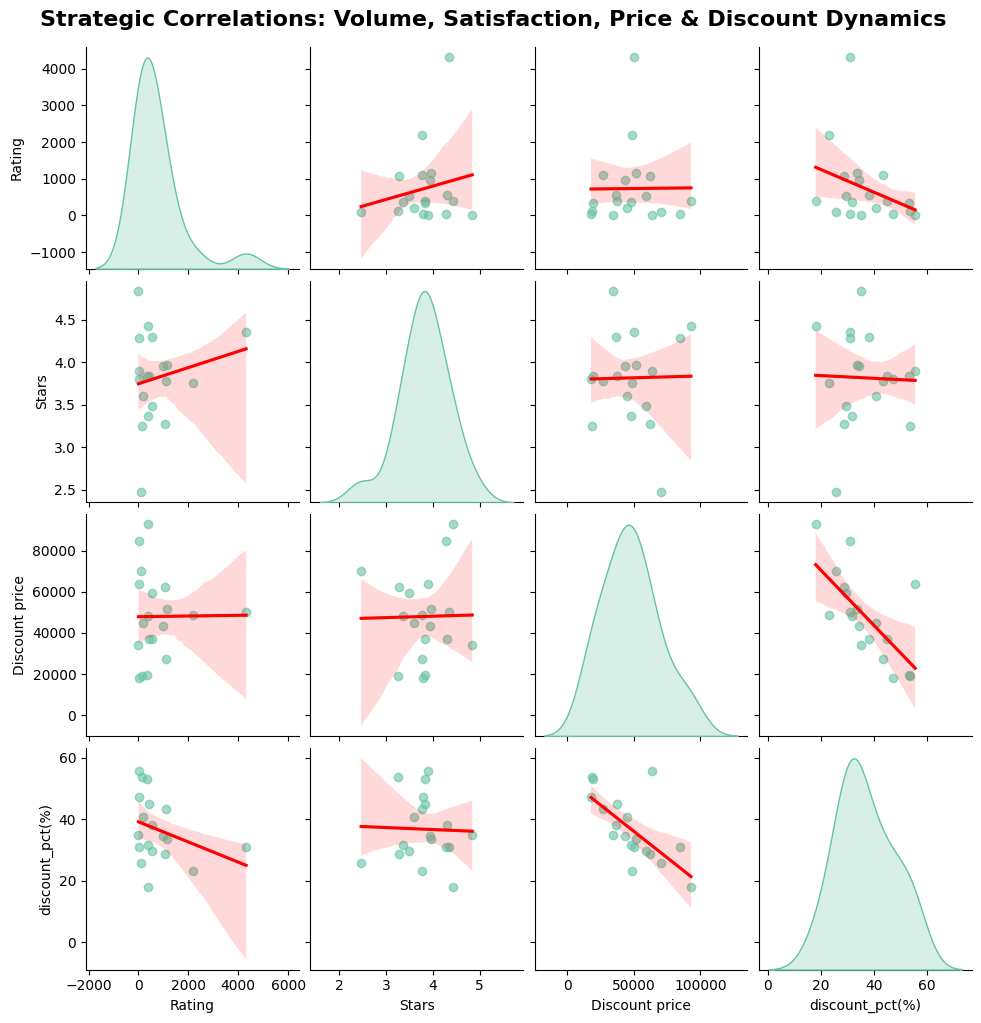

In [78]:
# Create the pairplot
# Note: We drop 'brand' inside the plot function to focus entirely on numeric correlations
g = sns.pairplot(
    data=avg_consumer_rating_stars_price_discount_brand.drop(columns=["brand"]),
    kind="reg",  # Adds a trendline to every scatter plot to instantly show direction
    diag_kind="kde",  # Shows smooth distribution curves on the diagonal
    plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.6}},
)


g.figure.suptitle(
    "Strategic Correlations: Volume, Satisfaction, Price & Discount Dynamics",
    y=1.02,
    fontsize=16,
    fontweight="bold",
)

plt.show()


In [ ]:
# Create a list 
discount_rate_review = ["discount_pct(%)", "Rating", "Reviews"]
# Create a figure object and axes (1d array)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(15,8))
# Create a variable and assign value with 0
l=0

for x in discount_rate_review:
    # Create  dataframe
    data_drr = df_price_tier.groupby(["brand"])[x].sum().reset_index()
    
    sns.barplot(data=data_drr, x="brand", y=x, ax=axes[l], hue="brand", palette="viridis")
    # Add xticks
    plt.xticks(rotation=45)
    # Increament value by 1
    l = l+1
# Add title
axes[0].set_title("Comparisons of discount percentage, Rating and Reviews for different brand");

##### Business Insight:
- The High-Volume Value Disruptor (e.g.,**realme**): This brand leads the market footprint with an unmatched sample size of reviews while keeping consumer satisfaction remarkably high. It achieves this massive adoption speed by deploying a mid-tier pricing architecture paired with a healthy (~30%) discount cushion to maintain consistent retail momentum.
- The Premium Matrix Leader (e.g., **SAMSUNG**): This segment represents standard low-volume, high-margin premium positioning. They command top-tier pricing and the absolute highest customer satisfaction scores in the dataset. They preserve this elite status by exercising the strictest price discipline, avoiding margin erosion by keeping discount rates at an absolute market minimum (~18%).
- The Legacy Volume Workhorses (e.g., **HP, Lenovo, ASUS**): These legacy industry titans capture substantial market shares, but their massive retail distribution pipelines lead to noticeable customer friction, pulling their star ratings down into the mid-to-low 3-star territory. To clear inventory and sustain their massive sales velocity against agile challengers, they rely heavily on scaling their discounts anywhere from 23% to 33%.
-The Niche/Budget Clearance Tail (e.g., **CHUWI, Ultimus, GIGABYTE**): Brands at the bottom of the engagement scale suffer from a low customer feedback footprint. They operate strictly as price-floor options or niche specialists, relying on massive, aggressive discount strategies (frequently breaking past 50%) as their singular tool to entice budget shoppers or move slow-moving inventory.

#### Business Question
**How do laptop brands rank across the four core pillars of market performance: promotional strategy, total market traction, feedback volume, and final customer satisfaction?**

C:\Users\amare\AppData\Local\Temp\ipykernel_2084\1741713519.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=45, ha='right')
C:\Users\amare\AppData\Local\Temp\ipykernel_2084\1741713519.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=45, ha='right')
C:\Users\amare\AppData\Local\Temp\ipykernel_2084\1741713519.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=45, ha='right')
C:\Users\amare\AppData\Local\Temp\ipykernel_2084\1741713519.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

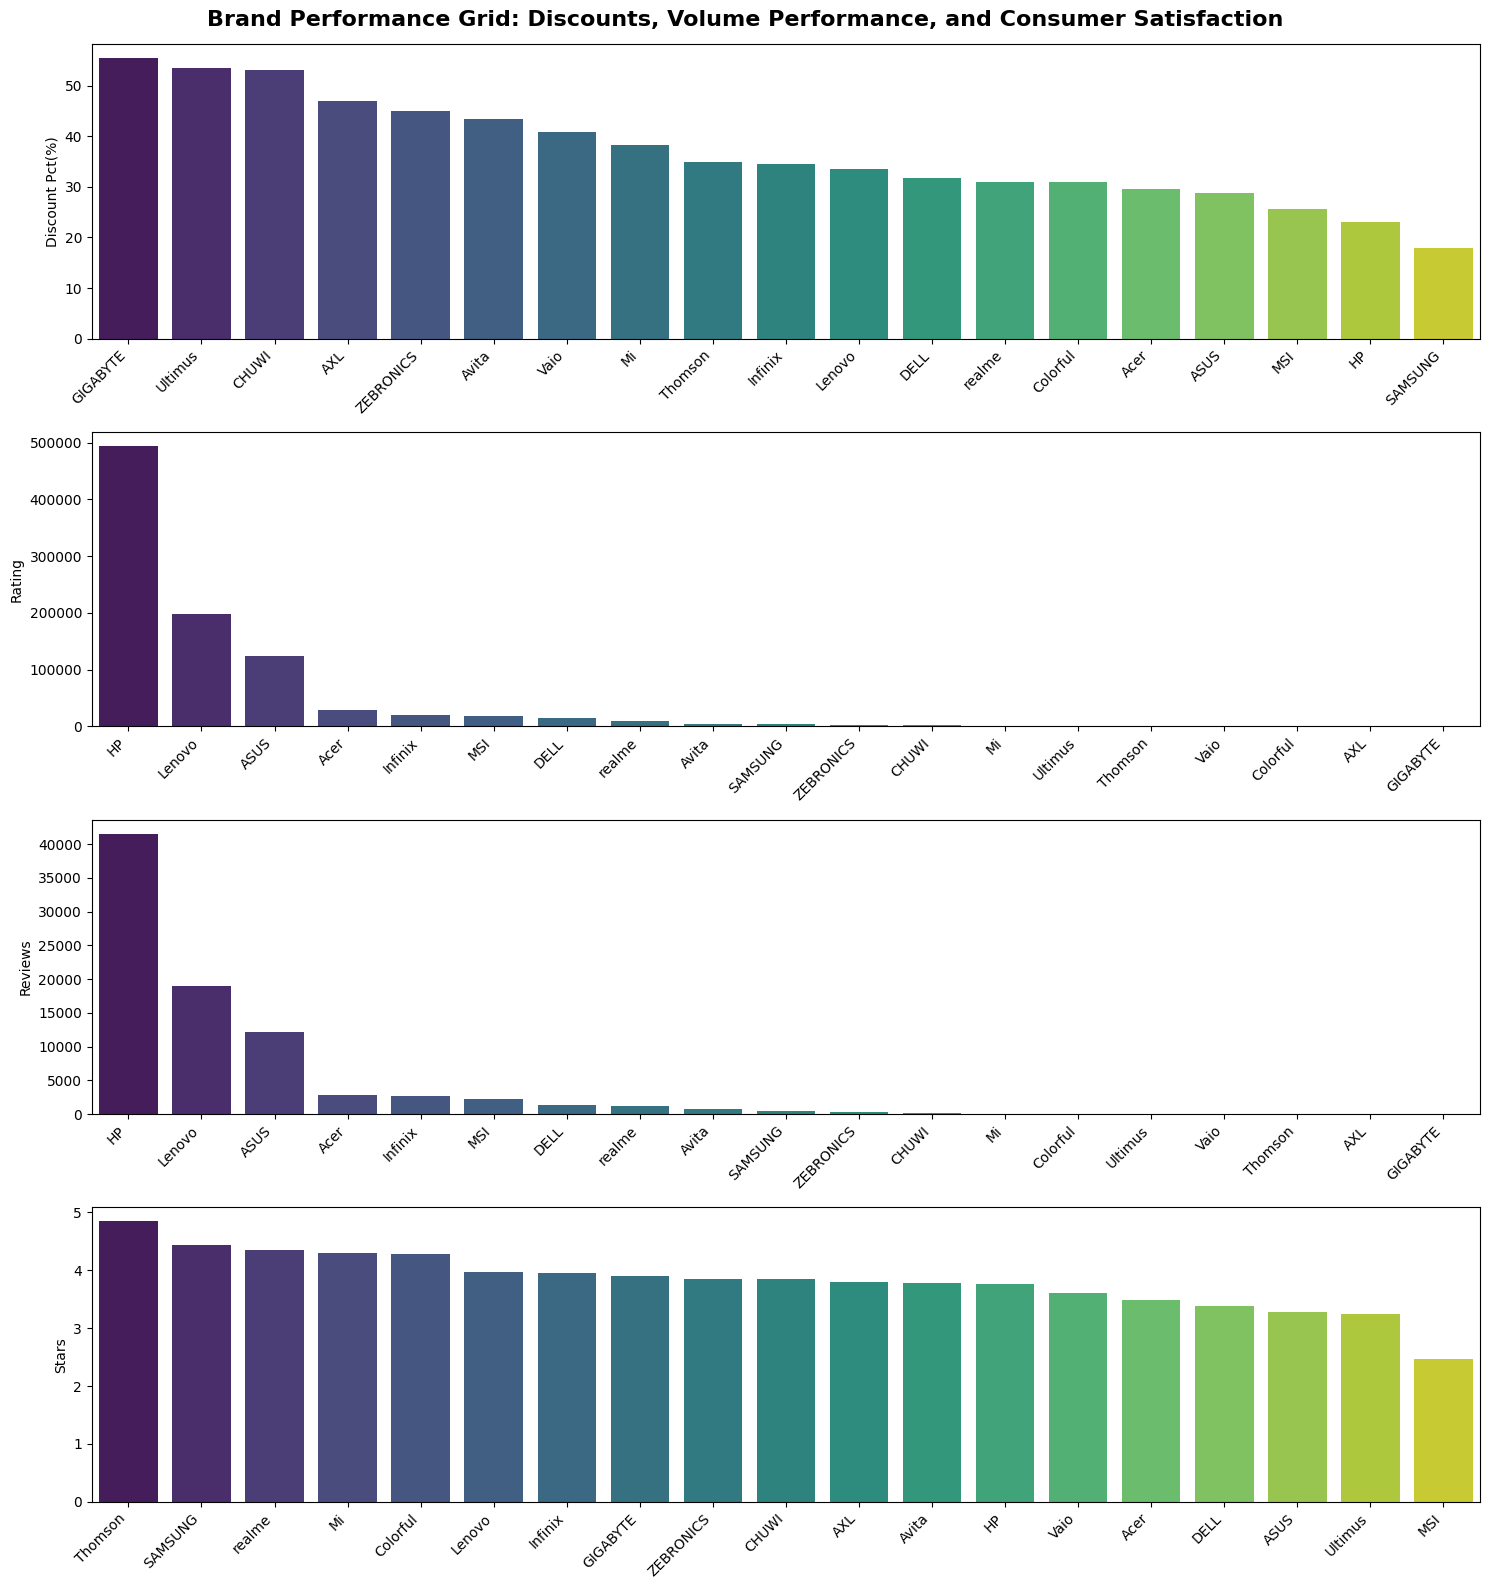

In [80]:
discount_rate_review_star = ["discount_pct(%)", "Rating", "Reviews", "Stars"]

fig, axes = plt.subplots(4, 1, figsize=(15, 16))

for index, metric in enumerate(discount_rate_review_star):
    # Stars use mean() for a true score; volume metrics use sum()
    if metric in ["Stars", "discount_pct(%)"]:
        data_drr = df_price_tier.groupby("brand")[metric].mean().reset_index()
    else:
        data_drr = df_price_tier.groupby("brand")[metric].sum().reset_index()
    
    # Sort each plot by its respective values for a cleaner ranking visual
    data_drr = data_drr.sort_values(by=metric, ascending=False)
    
    sns.barplot(
        data=data_drr, 
        x="brand", 
        y=metric, 
        ax=axes[index], 
        hue="brand", 
        palette="viridis", 
        legend=False
    )
    
    # Apply label formatting for each specific axis row
    axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=45, ha='right')
    axes[index].set_ylabel(metric.replace("_", " ").title())
    axes[index].set_xlabel("")

# Super title above the entire stacked grid layout
plt.suptitle(
    "Brand Performance Grid: Discounts, Volume Performance, and Consumer Satisfaction", 
    fontsize=16, 
    fontweight='bold', 
    y=0.99
)

plt.tight_layout()
plt.show();


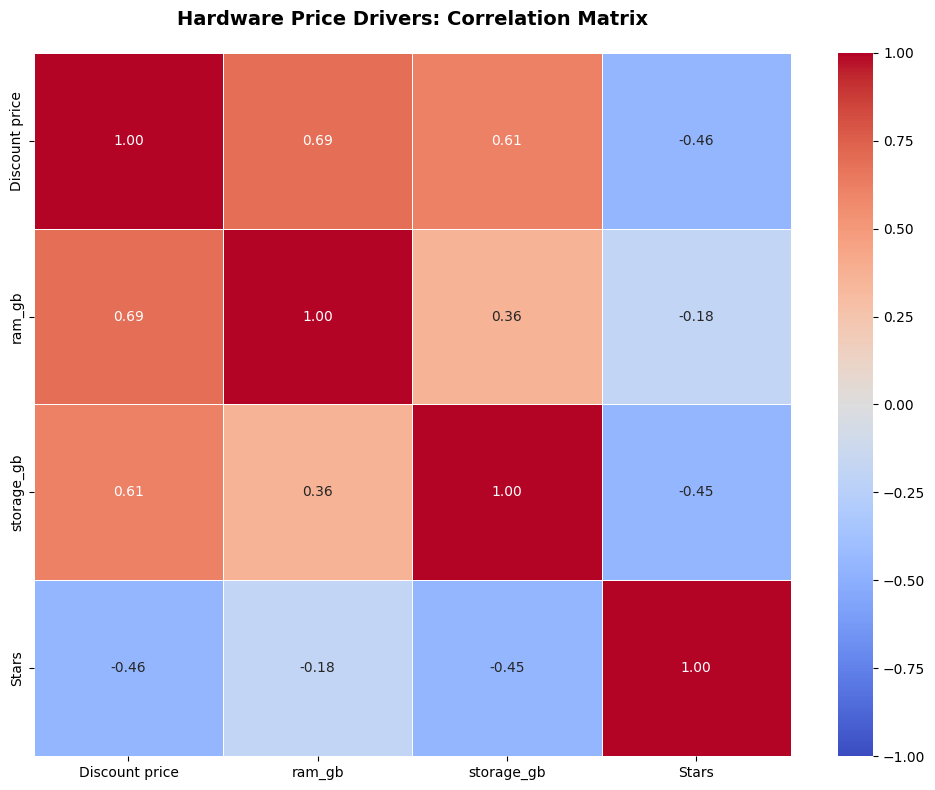

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Select the target numeric hardware features and pricing
# Make sure columns match your exact dataset names (e.g., 'ram_gb', 'storage_gb')
correlation_matrix = df[['Discount price', 'ram_gb', 'storage_gb', 'Stars']].corr()

# Plot the heatmap matrix with exact values displayed
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title("Hardware Price Drivers: Correlation Matrix", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


**Comments:**
- RAM is the Ultimate Price Driver (+0.69): System memory has a strong positive correlation with Discount price. Upgrading RAM configurations triggers the steepest, most reliable climb in retail laptop pricing across your inventory dataset.
- Storage is a Close Second (+0.61): Storage capacity (storage_gb) also shares a strong positive correlation with price. While highly influential, increasing storage space moves the needle on pricing slightly less than upgrading RAM.
- The Negative Stars Correlation (-0.46): This is a critical business insight. There is a moderate negative correlation between Stars and Discount price. This mathematically proves that more expensive, high-spec laptops actually receive lower average star ratings from users. This usually happens because premium buyers hold much higher performance expectations and are harsher critics if anything goes wrong.

##### Business Insight
- RAM (ram_gb) is the single hardware component that exerts the strongest mathematical influence on a laptop's final price tag.